In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


from chemevo import evolution_V1 as evo

# Sanders

### prompt element X
### constant SFR

In [130]:
SolarO = 73.3e-4
SolarFe = 13.7e-4
SolarMg = 6.71e-4
SolarMn = 1.29e-05 #Magg et al. 2022
SolarAl = 2.69e-6      #Magg et al. 2022

In [131]:
t = np.linspace(0.0001,14,int(1e3))
m_g = np.ones(len(t))
tau_star = 5
eta = 1
r = 0.4
m_O_cc = SolarO * (1 + eta - r)
tau_dep = tau_star / (1 + eta - r)
scale = 1

# For const SFR
Z_O_eq = m_O_cc / (1 + eta - r)
Z_O = Z_O_eq * (1 - np.exp(-t / tau_dep))

g_x = 1000

In [132]:
SolarO

0.00733

In [133]:
m_X_eq_weinberg = Z_O_eq 

In [134]:
g_x = (m_X_eq_weinberg - 1e-3)/(1e-3 * Z_O_eq)

In [135]:
g_x

863.5743519781719

In [136]:
Z_O_eq

0.00733

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_11655/2102564264.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


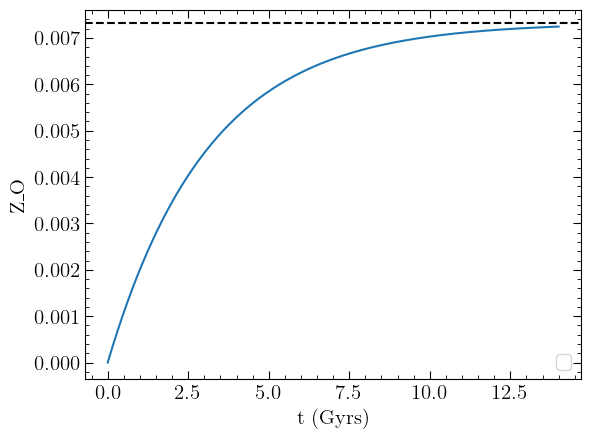

In [137]:
plt.plot(t, Z_O)
plt.axhline(Z_O_eq, color = 'black', linestyle='--')
plt.xlabel('t (Gyrs)')
plt.ylabel("Z_O")
plt.legend()

In [138]:
#Sanders:
m_O = Z_O * m_g
tau_x = tau_star/(g_x * m_O)

m_X_eq_weinberg = Z_O_eq 

m_x_0 = 0.001
Z_X_0 = m_x_0 * tau_dep / tau_star * (1 - np.exp(-t/tau_dep))
Z_X_1 = m_x_0 * tau_dep**2 / (tau_star * tau_x) * (1 - np.exp(-t/tau_dep) - (t/tau_dep) * np.exp(-t/tau_dep))
Z_X_sanders = Z_X_0 + Z_X_1

m_x_eq_sanders = m_x_0 * (1 + g_x * Z_O_eq)

In [139]:
#Weinberg

q = Z_O/Z_O_eq

Z_X_weinberg = Z_O * ( (m_X_eq_weinberg / m_O_cc) * (1 + (1-q)/q * np.log(1-q)) )

Text(0, 0.5, 'Z_X')

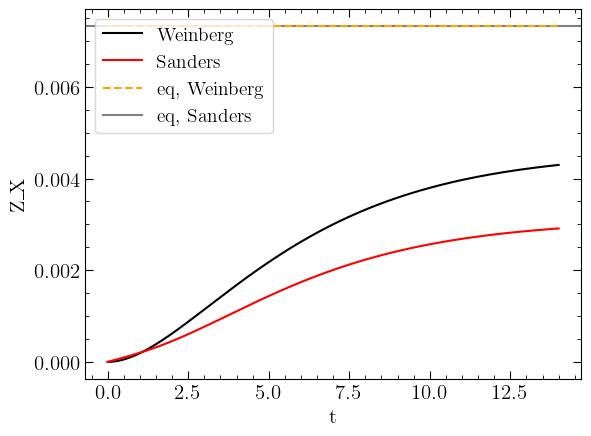

In [140]:
plt.plot(t, Z_X_weinberg, linestyle = '-', color = 'black', label = 'Weinberg')
plt.plot(t, Z_X_sanders, linestyle = '-', color = 'red', label = 'Sanders')
plt.plot(t, m_X_eq_weinberg/m_g, color = 'orange', linestyle = '--', label = 'eq, Weinberg', zorder=5)
plt.axhline(m_x_eq_sanders, color = 'gray', linestyle = '-', label = 'eq, Sanders')

plt.legend(loc = 'upper left')

plt.xlabel('t')
plt.ylabel('Z_X')

In [141]:
m_x_Z_weinberg = m_X_eq_weinberg * Z_O / Z_O_eq
m_x_Z_sanders = m_x_0 * (1 + g_x * Z_O)

Text(0.5, 1.0, '$Z_{X}$ as a function of $Z_{O}$')

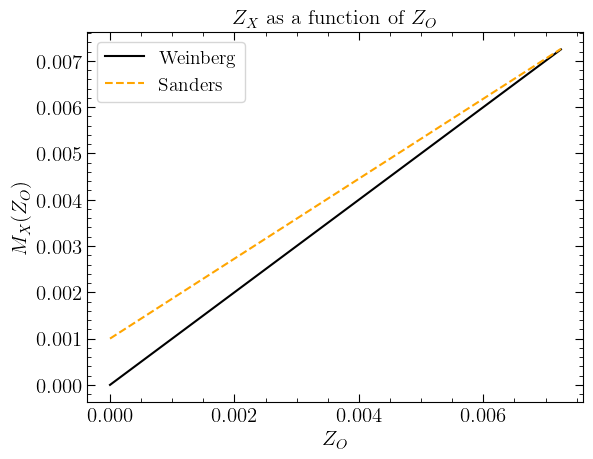

In [142]:
plt.plot(Z_O, m_x_Z_weinberg, color = 'black', label = 'Weinberg')
plt.plot(Z_O, m_x_Z_sanders, linestyle='--', color = 'orange', label = 'Sanders')
plt.legend()


plt.ylabel(r"$M_{X}(Z_{O})$")
plt.xlabel(r"$Z_{O}$")

plt.title(r"$Z_{X}$ as a function of $Z_{O}$")

In [143]:
def ratio_to_sun(star, sun):
        ratio = np.log10(star/sun + 1e-6)
        #ratio[np.where(ratio <= -10)] = 0
        return ratio

In [144]:
Mn_O_weinberg = ratio_to_sun(Z_X_weinberg, SolarMn) - ratio_to_sun(Z_O, SolarO)
Mn_O_Sanders = ratio_to_sun(Z_X_sanders, SolarMn) - ratio_to_sun(Z_O, SolarO)

In [145]:
from chemevo import evolution_V1 as evo
    
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]

m_g_array_const = np.ones(len(t_array))

In [146]:
galaxy = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_star,
                                     eta=eta, Upsilon=1, 
                                     yields_ref="sanders-test",
                                     g_cc_Mn=1, g_ratio_Mn=0,
                                     alpha_cc_Mn=1, alpha_Ia_Mn=1)

Text(0, 0.5, '$Z_{O}$')

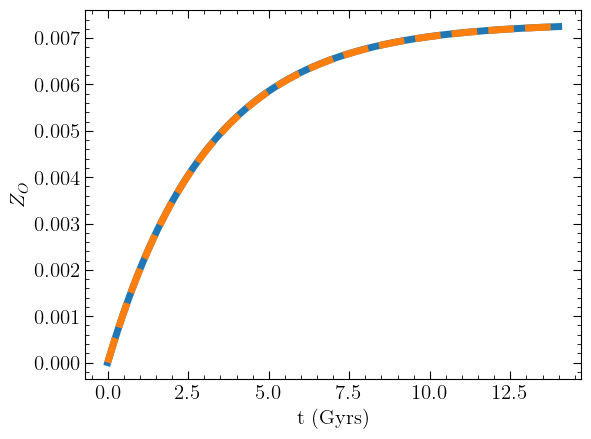

In [147]:
plt.plot(t_array, galaxy.compute_z_O(), linewidth=5, label = 'Numerical')
plt.plot(t_array, Z_O, linestyle = '--', linewidth=5, label = 'Analytical')

plt.xlabel("t (Gyrs)")
plt.ylabel(r"$Z_{O}$")

Text(0, 0.5, 'Z_X')

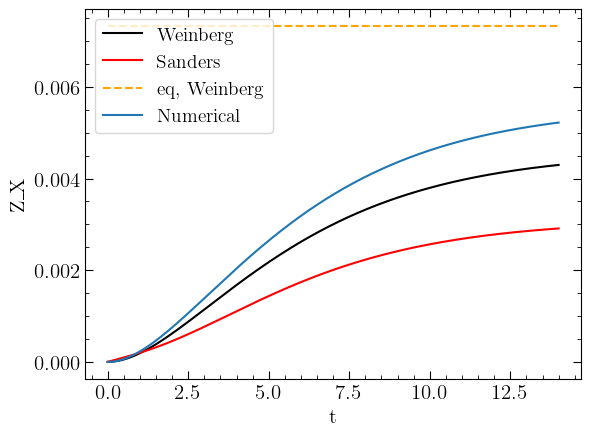

In [148]:
plt.plot(t, Z_X_weinberg, linestyle = '-', color = 'black', label = 'Weinberg')
plt.plot(t, Z_X_sanders, linestyle = '-', color = 'red', label = 'Sanders')
plt.plot(t, m_X_eq_weinberg/m_g, color = 'orange', linestyle = '--', label = 'eq, Weinberg')
plt.plot(t_array, galaxy.compute_z_T(), label = 'Numerical')
#plt.axhline(m_x_eq_sanders, color = 'gray', linestyle = '-', label = 'eq, Sanders')

plt.legend(loc = 'upper left')

plt.xlabel('t')
plt.ylabel('Z_X')

Text(0, 0.5, '[Mn/O]')

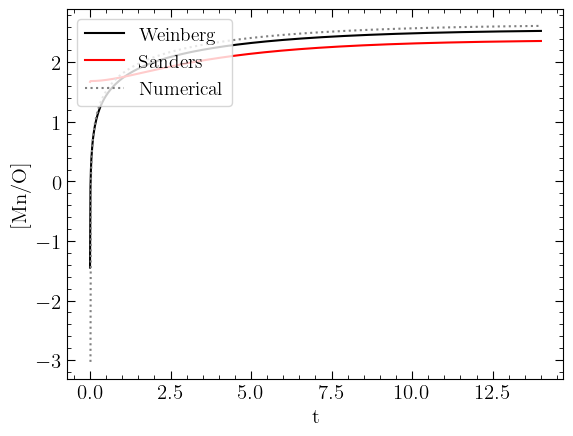

In [149]:
plt.plot(t, Mn_O_weinberg, linestyle = '-', color = 'black', label = 'Weinberg')
plt.plot(t, Mn_O_Sanders, linestyle = '-', color = 'red', label = 'Sanders')
plt.plot(t_array[1:], galaxy.T_O[1:], linestyle = ':', color = 'gray', label = 'Numerical')
#plt.plot(t, m_X_eq_weinberg/m_g, color = 'orange', linestyle = '--', label = 'eq, Weinberg')
#plt.axhline(m_x_eq_sanders, color = 'gray', linestyle = '-', label = 'eq, Sanders')

plt.legend(loc = 'upper left')

plt.xlabel('t')
plt.ylabel('[Mn/O]')

Text(0, 0.5, '[Mn/O]')

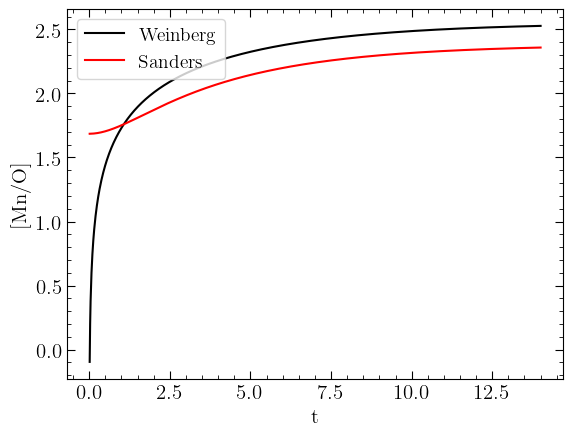

In [150]:
plt.plot(t[1:], Mn_O_weinberg[1:], linestyle = '-', color = 'black', label = 'Weinberg')
plt.plot(t[1:], Mn_O_Sanders[1:], linestyle = '-', color = 'red', label = 'Sanders')
#plt.plot(t_array[1:], galaxy.T_O[1:], linestyle = ':', color = 'gray', label = 'Numerical')
#plt.plot(t, m_X_eq_weinberg/m_g, color = 'orange', linestyle = '--', label = 'eq, Weinberg')
#plt.axhline(m_x_eq_sanders, color = 'gray', linestyle = '-', label = 'eq, Sanders')

plt.legend(loc = 'upper left')

plt.xlabel('t')
plt.ylabel('[Mn/O]')

In [151]:
Mn_O_Sanders[-1]

np.float64(2.3583604522438235)

In [152]:
Mn_O_weinberg[-1]

np.float64(2.5274972331078995)